In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import percentileofscore

## Configuration

In [2]:
DB_DIR = "../example_data"

PATTERN_MATCHES_DB = f"{DB_DIR}/pattern_matches.db"

OBL_TRANSACTIONS_ACTOR_COUNTS = "trans_actor_eluskoht_count"

#or alternatively for original data
GRAPH_DATA_DIR = "graph_data_files/"
ORIGINAL_ROOT_COUNT_FILE = f"{GRAPH_DATA_DIR}verbs_wcomps_obl_actor_root_perloc_counts.csv"


## Connect to db

In [3]:
con = sqlite3.connect(PATTERN_MATCHES_DB)
cur = con.cursor()

## Workflow

In [4]:
query = """SELECT * from {tbl}""".format(tbl=OBL_TRANSACTIONS_ACTOR_COUNTS)
source3 = pd.read_sql_query(query, con)
source3

,root_word,root_cnt,elus_cnt,mitte_elus_cnt,koht_cnt
0,1.,1,0,0,0
1,Beatrice,2,0,0,0
2,Eesti,1,0,1,0
3,Gunnar,2,0,0,0
4,Harvard,1,0,0,0
...,...,...,...,...,...
187,õlg,1,0,1,1
188,ühing,1,0,0,0
189,üksteise,1,0,1,1
190,üritus,1,0,1,0


Or alternatively

In [3]:
source3 = pd.read_csv(ORIGINAL_ROOT_COUNT_FILE, sep=",", encoding="utf-8")
source3

,root_word,root_cnt,elus_cnt,mitte_elus_cnt
0,,5,0,0
1,%p2tu,1,0,0
2,%reimo,1,0,0
3,/O,2,0,0
4,/P,1,0,0
...,...,...,...,...
410714,█████████,1,0,0
410715,██████████,1,0,0
410716,□,2,0,0
410717,�,13,0,0


Add columns for total annotated and divisions. Take only rows where total is >0 and sort in ascending order. Calculate percentiles.

In [4]:
source3["elus_div"] = source3["elus_cnt"]/source3["root_cnt"]
source3["koht_div"] = source3["mitte_elus_cnt"]/source3["root_cnt"]
source3["total"] = source3["elus_cnt"]+source3["mitte_elus_cnt"]
source3 = source3[source3["total"]>0]
source3["elus/total"] = source3["elus_cnt"]/source3["total"]
source3["mitteelus/total"] = source3["mitte_elus_cnt"]/source3["total"]
source3 = source3.sort_values(by=["elus/total"])
source3["elus/total percentile"] = [round(percentileofscore(source3["elus/total"], i, kind='strict')) for i in source3["elus/total"]]
source3 = source3.sort_values(by=["mitteelus/total"])
#source3 = source3.sort_values(by=["total"])
source3["mitteelus/total percentile"] = [round(percentileofscore(source3["mitteelus/total"], i, kind='strict')) for i in source3["mitteelus/total"]]

/tmp/ipykernel_19163/3186383598.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source3["elus/total"] = source3["elus_cnt"]/source3["total"]
/tmp/ipykernel_19163/3186383598.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source3["mitteelus/total"] = source3["mitte_elus_cnt"]/source3["total"]


In [58]:
source3

,root_word,root_cnt,elus_cnt,mitte_elus_cnt,elus_div,koht_div,total,elus/total,mitteelus/total,elus/total percentile,mitteelus/total percentile
163,$,321,0,1,0.000000,0.003115,1,0.000000,1.000000,0,17
125836,blogikeskkond,1,0,1,0.000000,1.000000,1,0.000000,1.000000,0,17
125574,biomeditsiiniinstituut,1,0,1,0.000000,1.000000,1,0.000000,1.000000,0,17
125849,blogiväljavõte,1,0,1,0.000000,1.000000,1,0.000000,1.000000,0,17
125871,blokikäsi,1,0,1,0.000000,1.000000,1,0.000000,1.000000,0,17
...,...,...,...,...,...,...,...,...,...,...,...
323763,see,307408,1926,58656,0.006265,0.190808,60582,0.031792,0.968208,85,15
35818,Eesti,95370,1981,63619,0.020772,0.667076,65600,0.030198,0.969802,84,16
251215,mina,246340,60665,21946,0.246265,0.089088,82611,0.734345,0.265655,92,8
342326,sõna,160602,11184,93507,0.069638,0.582228,104691,0.106829,0.893171,87,13


In [26]:
source3 = source3.sort_values(by=["elus/total"])

In [27]:
source3.quantile(.95, numeric_only=True)

root_cnt                      110.000000
elus_cnt                        2.000000
mitte_elus_cnt                 29.000000
elus_div                        0.333333
koht_div                        1.000000
total                          33.000000
elus/total                      1.000000
mitteelus/total                 1.000000
elus/total percentile          93.000000
mitteelus/total percentile     17.000000
Name: 0.95, dtype: float64

elus 0.95 quantile

In [28]:
elusquant95 = source3["elus/total"].quantile(.95)
elusquant95

1.0

mitte elus 0.95 quantile

In [29]:
mitteelusquant95 = source3["mitteelus/total"].quantile(.95)
mitteelusquant95

1.0

Coloring for graph. Mark values that are in the 95th quantile and percentile >=90. 

In [63]:
colors = {}
for i in range(len(source3)):
    div1 = source3.iloc[i]["elus/total"]
    div2 = source3.iloc[i]["mitteelus/total"]
    percent1 = source3.iloc[i]["elus/total percentile"]
    percent2 = source3.iloc[i]["mitteelus/total percentile"]
    word = source3.iloc[i]["root_word"]
    if div1 >= elusquant95  and percent1>=90:
        colors[word] = "red"
    elif div2 >= mitteelusquant95  and percent2>=90:
        colors[word] = "blue"
    elif percent2>=17:
        colors[word] = "orange"
    else:
        colors[word] = "yellow"

Dict for dot size base don root count.

In [31]:
areadict = {}
root_cnts = sorted(list(set(list(source3["total"])))) 

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 5
    elif cnt >=10 and cnt < 100: areadict[cnt] = 10
    elif cnt >=100 and cnt < 1000: areadict[cnt] = 30
    #elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 5000: areadict[cnt] = 50
    #elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 20000: areadict[cnt] = 80
    #elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=20000 and cnt < 50000: areadict[cnt] = 100
    elif cnt >=50000: areadict[cnt] = 200

# TAVAPLOT

### normaliseeritud väärtustega pilt, total count >=10

In [64]:
source4 = source3[source3["total"]>=10]
#source4 = source4[(source4["elus_div"]>=0.05) & (source4["koht_div"]>=0.05)]
#source4 = source4[(source4["elus_div"]>=3*source4["koht_div"]) | (source4["koht_div"]>=3*source4["elus_div"])]

roots = list(source4["total"])
kohad =  list(source4["koht_div"])
elusad = list(source4["elus_div"])
words = list(source4["root_word"])

# quantiles
quantile_05 = source4['koht_div'].quantile(0.05)
quantile_25 = source4['koht_div'].quantile(0.25)
quantile_50 = source4['koht_div'].quantile(0.5)
quantile_70 = source4['koht_div'].quantile(0.7)
quantile_80 = source4['koht_div'].quantile(0.8)
quantile_90 = source4['koht_div'].quantile(0.9)


quantile_05_2 = source4['elus_div'].quantile(0.05)
quantile_25_2 = source4['elus_div'].quantile(0.25)
quantile_50_2 = source4['elus_div'].quantile(0.5)
quantile_70_2 = source4['elus_div'].quantile(0.7)
quantile_80_2 = source4['elus_div'].quantile(0.8)
quantile_90_2 = source4['elus_div'].quantile(0.9)

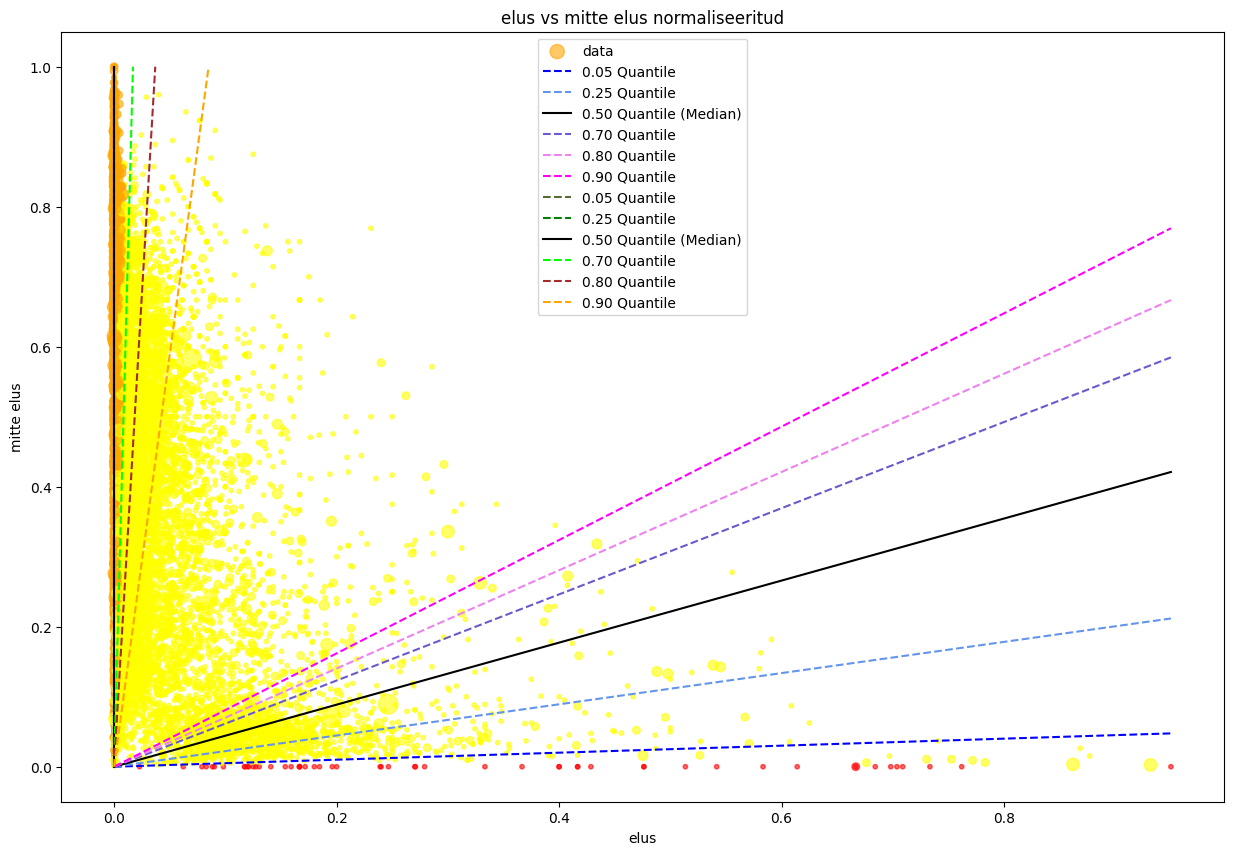

In [65]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad

area = [areadict[cnt] for cnt in roots]
color = [colors[cnt] for cnt in words]
plt.scatter(x, y, s=area, c=color, alpha=0.6, label="data")

# quantiles elus
plt.plot([0, max(elusad)], [0, quantile_05], color='blue', linestyle='--', label='0.05 Quantile')
plt.plot([0, max(elusad)], [0, quantile_25], color='cornflowerblue', linestyle='--', label='0.25 Quantile')
plt.plot([0, max(elusad)], [0, quantile_50], color='black', linestyle='-', label='0.50 Quantile (Median)')
plt.plot([0, max(elusad)], [0, quantile_70], color='slateblue', linestyle='--', label='0.70 Quantile')
plt.plot([0, max(elusad)], [0, quantile_80], color='violet', linestyle='--', label='0.80 Quantile')
plt.plot([0, max(elusad)], [0, quantile_90], color='magenta', linestyle='--', label='0.90 Quantile')

# quantiles mitte elus
plt.plot([0, quantile_05_2], [0, max(kohad)], color='darkolivegreen', linestyle='--', label='0.05 Quantile')
plt.plot([0, quantile_25_2], [0, max(kohad)], color='green', linestyle='--', label='0.25 Quantile')
plt.plot([0, quantile_50_2], [0, max(kohad)], color='black', linestyle='-', label='0.50 Quantile (Median)')
plt.plot([0, quantile_70_2], [0, max(kohad)], color='lime', linestyle='--', label='0.70 Quantile')
plt.plot([0, quantile_80_2], [0, max(kohad)], color='brown', linestyle='--', label='0.80 Quantile')
plt.plot([0, quantile_90_2], [0, max(kohad)], color='orange', linestyle='--', label='0.90 Quantile')

plt.title("elus vs mitte elus normaliseeritud")
plt.ylabel("mitte elus")
plt.xlabel("elus")
plt.legend()
plt.show()

In [ ]:
con.close()